In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import expon
from bayesian_dro.Bayesian_DRO_continuous import data_generation
from mis_dro.dataset import data_generation_outliers, data_generation_gamma
from bayesian_dro.Bayesian_DRO_continuous import EPSILON_SET

/tmp/dcs-tmp.u1604520/ipykernel_477818/2478035765.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
experiment_dir = "/dcs/pg23/u1604520/misdro/results_kdro/"
experiment_dir_bdro = "/dcs/pg23/u1604520/misdro/results_kdro/bdro/"
# results_df = pd.read_csv(experiment_dir / "results.csv", index_col="uuid")
#results_other_dgps_df = pd.read_csv(experiment_dir / "results_patrick.csv", index_col="uuid")
#results_df = pd.concat([results_other_dgps_df, results_gamma_df])
dfs = []
for dir in [experiment_dir, experiment_dir_bdro]:
    for epsilon in EPSILON_SET:
        file_path = dir + f"test_results_eps_{epsilon}.csv"
        df = pd.read_csv(file_path)
        df['epsilon'] = epsilon
        if dir == experiment_dir:
            df['algorithm'] = 'mmd-dro'
        else:
            df['algorithm'] = 'bdro'
        dfs.append(df)
results_df = pd.concat(dfs, ignore_index=True)
# check the number of train/test observations is the same:
# assert len(results_df["num_observations"].unique()) == 1
# assert len(results_df["num_test_observations"].unique()) == 1
# num_observations = results_df["num_observations"]
# num_test_observations = results_df["num_test_observations"]
results_df

,replication,mean_cost,var_cost,solution,dgp_time,likelihood_time,posterior_time,solve_time,epsilon,algorithm
0,0,39.233718,390.122454,20.638453,0.000546,0.004695,68.215698,12.178515,0.001,mmd-dro
1,1,33.106690,1704.298042,13.042162,0.000621,0.003703,54.614185,13.369725,0.001,mmd-dro
2,2,34.932112,2359.851775,10.369878,0.000702,0.001980,36.645806,12.013488,0.001,mmd-dro
3,3,46.556909,3098.947802,13.472721,0.000680,0.001676,34.272694,11.261843,0.001,mmd-dro
4,4,39.278303,627.938460,20.198582,0.000617,0.001911,33.700322,11.337103,0.001,mmd-dro
...,...,...,...,...,...,...,...,...,...,...
3595,95,88.107677,389.557044,38.870000,0.000430,0.000517,0.000100,207.862483,3.000,bdro
3596,96,189.016347,578.769576,73.120000,0.000445,0.000523,0.000102,236.699764,3.000,bdro
3597,97,95.984518,379.030654,39.910000,0.000434,0.000519,0.000102,210.179463,3.000,bdro
3598,98,51.659852,1775.740988,21.140000,0.000430,0.000526,0.000102,203.890816,3.000,bdro


In [3]:
# results_df = results_df[results_df['epsilon'] < 0.2]

In [4]:
gb = results_df.groupby(by=["algorithm", "epsilon"])
df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    "posterior_time": ["mean"],
    "solve_time": ["mean"],
    "solution": ["mean", "var"]
})
df

mean_cost                  var_cost posterior_time  \
                         mean          var         mean           mean   
algorithm epsilon                                                        
bdro      0.001     46.778913   218.072904  1244.578555       0.000105   
          0.002     47.221901   226.827771  1227.394242       0.000105   
          0.005     47.813531   247.652947  1201.847596       0.000105   
          0.010     48.682826   259.644103  1168.958636       0.000105   
          0.020     49.793220   277.252508  1123.074588       0.000105   
          0.050     52.036289   325.664386  1048.161816       0.000105   
          0.100     55.007385   429.462835   980.885118       0.000105   
          0.150     57.358041   514.357163   937.929406       0.000105   
          0.200     59.564831   612.893008   907.710262       0.000105   
          0.250     61.466580   689.828792   883.992083       0.000105   
          0.300     63.512796   770.443805   861.514861       0.000105   
          0.400     67.166462   952.837201   830.409502       0.000105   
          0.500     70.001981  1088.211121   807.014141       0.000105   
          1.000     81.317497  1519.199616   763.353942       0.000105   
          1.500     85.466367  1654.572049   760.629912       0.000105   
          2.000     96.984910  2015.629473   702.973601       0.000105   
          2.500     96.989460  2015.572356   702.958112       0.000105   
          3.000     96.989460  2015.572356   702.958112       0.000105   
mmd-dro   0.001     39.651010    98.739069  1690.561149      33.685211   
          0.002     39.671471    97.558900  1685.445927      33.685211   
          0.005     39.738299    96.857109  1667.725685      33.685211   
          0.010     39.854921    95.817858  1645.121381      33.685211   
          0.020     40.036420    95.108072  1606.280594      33.685211   
          0.050     40.712034    94.772183  1487.675658      33.685211   
          0.100     42.531988   100.236852  1280.866041      33.685211   
          0.150     45.160882   117.436322  1091.193840      33.685211   
          0.200     49.369488   156.299080   930.550267      33.685211   
          0.250     59.338866   385.208248   786.739929      33.685211   
          0.300     77.842359  1331.331027   739.031924      33.685211   
          0.400    106.021143  2606.065521   684.992000      33.685211   
          0.500    109.320453  2733.186385   683.131719      33.685211   
          1.000    111.009999  2814.171205   683.711790      33.685211   
          1.500    111.009999  2814.171205   683.711789      33.685211   
          2.000    111.009999  2814.171194   683.711789      33.685211   
          2.500    111.009999  2814.171201   683.711789      33.685211   
          3.000    111.009999  2814.171197   683.711789      33.685211   

                   solve_time   solution              
                         mean       mean         var  
algorithm epsilon                                     
bdro      0.001    208.016941  19.970800   49.429315  
          0.002    208.016941  20.207400   51.028985  
          0.005    208.016941  20.555800   53.905301  
          0.010    208.016941  21.044200   56.009994  
          0.020    208.016941  21.675400   58.464995  
          0.050    208.016941  22.917100   64.916627  
          0.100    208.016941  24.384700   77.672498  
          0.150    208.016941  25.507100   87.380219  
          0.200    208.016941  26.486900   98.839143  
          0.250    208.016941  27.332200  107.105654  
          0.300    208.016941  28.201700  115.809976  
          0.400    208.016941  29.705000  136.204490  
          0.500    208.016941  30.839300  151.245043  
          1.000    208.016941  35.112200  201.609795  
          1.500    208.016941  36.612700  217.426919  
          2.000    208.016941  40.905700  252.495372  
          2.500    208.016941  40.907400  252.485355  
          3.000    208.016941  40

In [5]:
def plot_dgp(df, dgp: str, axis):
    # get a dataframe for each posterior
    bayes_df = df.loc["bdro", :]
    # wll_df = df.loc[algorithm, dgp, :, "wll"]
    mmd_df = df.loc["mmd-dro", :]

    # # mean of variances + variance of means
    bayes_bootstrap_var = bayes_df["var_cost"]["mean"] + bayes_df["mean_cost"]["var"]
    # wll_bootstrap_var = wll_df["var_cost"]["mean"] + wll_df["mean_cost"]["var"]
    mmd_bootstrap_var = mmd_df["var_cost"]["mean"] + mmd_df["mean_cost"]["var"]

    # plot mean-variance trade-off
    axis.plot(bayes_bootstrap_var, bayes_df["mean_cost"]["mean"], marker='o', linestyle="solid", label="Bayesian")
    # axis.plot(wll_bootstrap_var, wll_df["mean_cost"]["mean"], marker="x", linestyle="dashed", label="WLL-NPL")
    axis.plot(mmd_bootstrap_var, mmd_df["mean_cost"]["mean"], marker="v", linestyle="dotted", label="MMD-NPL")

    # set title and label epsilon
    axis.set_title(f"DGP is {dgp}")
    axis.legend()
    axis.set_xlabel("out-of-sample variance")
    axis.set_ylabel("out-of-sample mean")
    for i, epsilon in enumerate(mmd_df.index.get_level_values("epsilon")):
        if i % 4 == 0:
            axis.text(bayes_bootstrap_var[epsilon], bayes_df["mean_cost"]["mean"][epsilon], epsilon, ha='left', va='bottom')
        if (i+2) % 4 == 0:
            axis.text(mmd_bootstrap_var[epsilon], mmd_df["mean_cost"]["mean"][epsilon], epsilon, ha='right', va='bottom')

# plot mean-variance trade-off for each DGP
# dgp_list = list(df.index.get_level_values("dgp").unique())
# nrows = int(np.ceil(len(dgp_list)/2.0))
# fig, axes = plt.subplots(nrows=nrows, ncols=2, sharex=False, sharey=False, figsize=(10,10))
# for i, dgp in enumerate(dgp_list):
#     row = int(np.floor(i / 2.0))
#     col = i % 2
#     plot_dgp(dgp, axes[row][col])

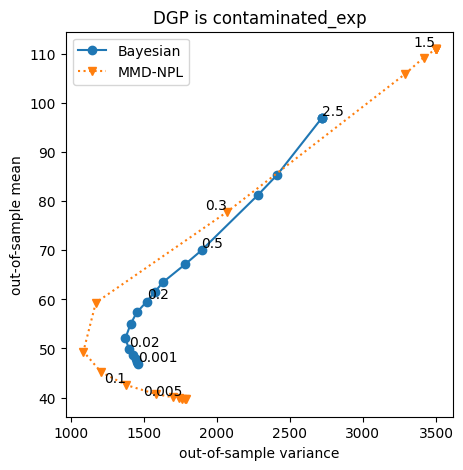

In [6]:
fig, ax = plt.subplots(nrows=1, ncols=1, sharex=False, sharey=False, figsize=(5,5))
plot_dgp(df, 'contaminated_exp', ax)

In [30]:
from scipy.stats import truncnorm
b = 8
h = 3
L = 100

DGP_MEAN_TRUNCATED_NORMAL = 10
DGP_STD_TRUNCATED_NORMAL = 10

NUM_OBSERVATIONS = 20
sol_true = truncnorm.ppf(
        (b - 0) / (h + b), a=-DGP_MEAN_TRUNCATED_NORMAL / DGP_STD_TRUNCATED_NORMAL, b=np.inf, loc=DGP_MEAN_TRUNCATED_NORMAL, scale=DGP_STD_TRUNCATED_NORMAL
    )

In [26]:
sol_true

17.406341169581744

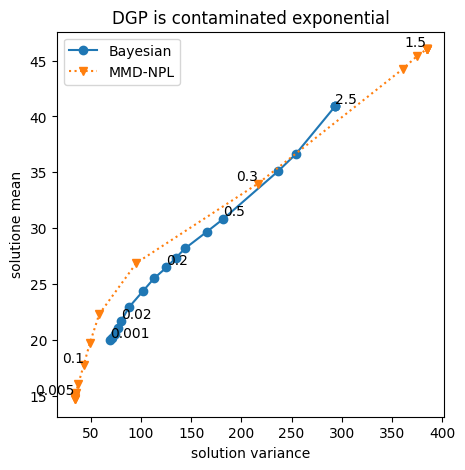

In [34]:
fig, ax = plt.subplots(nrows=1, ncols=1, sharex=False, sharey=False, figsize=(5,5))
bayes_df = df.loc["bdro", :]
mmd_df = df.loc["mmd-dro", :]

bayes_bootstrap_var = bayes_df["solution"]["mean"] + bayes_df["solution"]["var"]
mmd_bootstrap_var = mmd_df["solution"]["mean"] + mmd_df["solution"]["var"]

# plot mean-variance trade-off
ax.plot(bayes_bootstrap_var, bayes_df["solution"]["mean"], marker='o', linestyle="solid", label="Bayesian")
    # axis.plot(wll_bootstrap_var, wll_df["mean_cost"]["mean"], marker="x", linestyle="dashed", label="WLL-NPL")
ax.plot(mmd_bootstrap_var, mmd_df["solution"]["mean"], marker="v", linestyle="dotted", label="MMD-NPL")

# set title and label epsilon
ax.set_title("DGP is contaminated exponential")
ax.legend()
ax.set_xlabel("solution variance")
ax.set_ylabel("solution mean")
for i, epsilon in enumerate(mmd_df.index.get_level_values("epsilon")):
    if i % 4 == 0:
        ax.text(bayes_bootstrap_var[epsilon], bayes_df["solution"]["mean"][epsilon], epsilon, ha='left', va='bottom')
    if (i+2) % 4 == 0:
        ax.text(mmd_bootstrap_var[epsilon], mmd_df["solution"]["mean"][epsilon], epsilon, ha='right', va='bottom')